Aim

To generate a random dataset following a quadratic distribution and classify the data using Support Vector Machine (SVM).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

This creates 200 data points

In [2]:
np.random.seed(5)

# Number of samples
n = 200

# Generate X values
X1 = np.random.uniform(-5, 5, n)
X2 = np.random.uniform(-5, 5, n)

# Quadratic boundary
boundary = X1**2 + X2**2

# Create two classes
y = np.where(boundary > 9, 1, 0)

# Create dataframe
df = pd.DataFrame({
    'X1': X1,
    'X2': X2,
    'Class': y
})

print(df.head(10))
print("\nDataset Shape:", df.shape)

         X1        X2  Class
0 -2.780068 -1.522708      1
1  3.707323 -4.871519      1
2 -2.932808 -3.343582      1
3  4.186109 -4.396336      1
4 -0.115888 -2.218441      0
5  1.117439 -1.516680      0
6  2.659079  0.912223      0
7  0.184180  2.750131      0
8 -2.031995  1.247545      0
9 -3.122788 -3.403191      1

Dataset Shape: (200, 3)


In [3]:
print("Class Distribution:")
print(df['Class'].value_counts())

print("\n0 = Class 0")
print("1 = Class 1")

Class Distribution:
Class
1    142
0     58
Name: count, dtype: int64

0 = Class 0
1 = Class 1


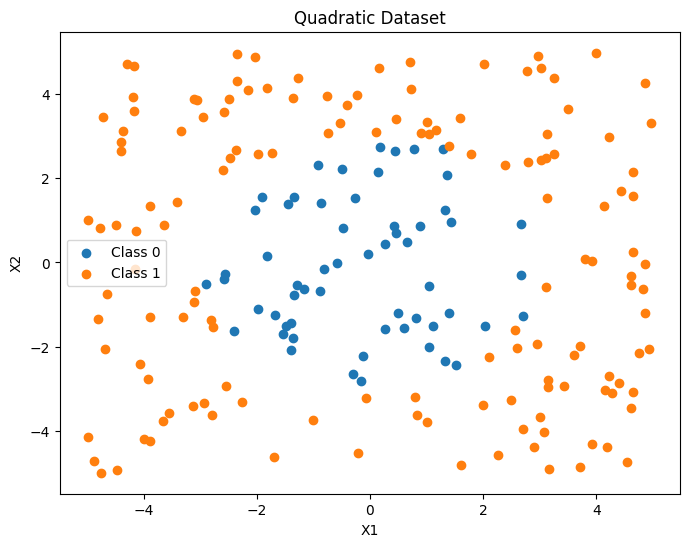

In [4]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df[df['Class'] == 0]['X1'],
    df[df['Class'] == 0]['X2'],
    label='Class 0'
)

plt.scatter(
    df[df['Class'] == 1]['X1'],
    df[df['Class'] == 1]['X2'],
    label='Class 1'
)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Quadratic Dataset')
plt.legend()
plt.show()

In [5]:
X = df[['X1', 'X2']]
y = df['Class']

print("Independent Variables:")
print(X.head())

print("\nDependent Variable:")
print(y.head())

Independent Variables:
         X1        X2
0 -2.780068 -1.522708
1  3.707323 -4.871519
2 -2.932808 -3.343582
3  4.186109 -4.396336
4 -0.115888 -2.218441

Dependent Variable:
0    1
1    1
2    1
3    1
4    0
Name: Class, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=5,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 2)
Testing data: (40, 2)


In [7]:
model = SVC(
    kernel='poly',
    degree=2,
    random_state=5
)

model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [8]:
y_pred = model.predict(X_test)

print("Actual Values:")
print(y_test.values)

print("\nPredicted Values:")
print(y_pred)

Actual Values:
[0 1 0 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 0 1 1 1 1 1
 0 1 1]

Predicted Values:
[0 1 0 1 1 1 0 1 1 0 1 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 1 1 0 1 1 1 1 1
 0 1 1]


In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)
print("Accuracy in Percentage:", accuracy * 100, "%")

Accuracy Score: 0.975
Accuracy in Percentage: 97.5 %


In [10]:
conf_mat = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(conf_mat)

Confusion Matrix:
[[11  1]
 [ 0 28]]


In [11]:
print("Classification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.97      1.00      0.98        28

    accuracy                           0.97        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.98      0.97      0.97        40



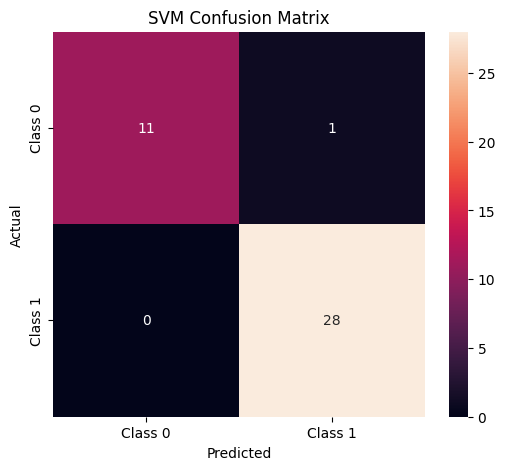

In [12]:
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_mat,
    annot=True,
    fmt='d',
    xticklabels=['Class 0', 'Class 1'],
    yticklabels=['Class 0', 'Class 1']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

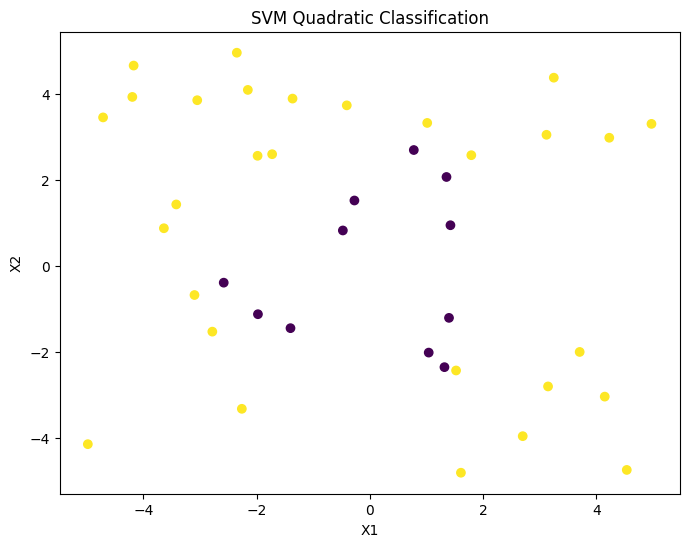

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_test['X1'],
    X_test['X2'],
    c=y_pred
)

plt.xlabel('X1')
plt.ylabel('X2')
plt.title('SVM Quadratic Classification')
plt.show()

Result

A quadratic dataset was generated and an SVM classifier with a polynomial kernel of degree 2 was trained. The model successfully classified the two classes, and its performance was evaluated using accuracy, confusion matrix and classification report.